# Introduction

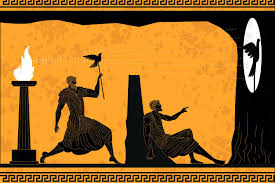

[Allegory of the Cave](https://en.wikipedia.org/wiki/Allegory_of_the_cave)

People chained can only see the 2 dimensional shadow projected onto a wall. But it is generated by unseen 3 dimensional objects passed before a fire. To such people, everything they observe
is actually determined by higher-dimensional abstract concepts that they can never behold.

Similarly, the objects that we encounter in the actual world may also be generated as a function of some higher level representations.

for example, such representations may encapsulate abstract properties
such as color, size, shape, and more.

Plato’s Allegory illustrates the idea behind latent variables as potentially unobservable representations that determine observations.

Similarly, in generative models, we aim to learn latent representations of data. Typically, we prefer these representations to be lower-dimensional rather than higher-dimensional.

Now, someone might wonder why lower-dimensional and not higher?

Think of it like Plato’s cave. The person in chains lives in a world where they only see 2D shadows of real 3D objects. If they learn the structure and patterns of these 2D projections, they might be able to infer something about the underlying reality, even though they never directly observe it.

In the same way, in a Variational Autoencoder (VAE), we assume that high-dimensional data (like images) is generated from a simpler, lower-dimensional latent space. This latent space captures the essential factors of variation like shape, orientation, or style rather than every pixel independently.

If we instead used a higher-dimensional latent space, the model could simply memorize the data without learning meaningful structure. A lower dimensional latent space forces the model to compress the data, capturing only the most important underlying features much like trying to reconstruct the 3D world using only the limited information available in 2D shadows.

## Let's Define Our Model

Before deriving the ELBO, we need to think about what we're actually trying to optimize.

We can define the likelihood of our data as the **marginalization over the joint probability** with respect to the latent variable $z$:

$$p(x) = \int p(x, z)\, dz$$

### What is Marginalization?

Marginalization is the process of summing (or integrating) out variables you don't care about, so you are left with the distribution over only the variables you *do* care about.

Think of it this way: the joint distribution $p(x, z)$ tells us the probability of observing *both* a data point $x$ **and** a particular latent variable $z$ at the same time. But we only ever observe $x$ since $z$ is hidden. So to get the probability of just $x$ alone, we ask:

> "Over **all possible** values of $z$, what is the total probability of seeing this $x$?"

That's exactly what the integral does. It sums the joint probability over every possible $z$:

$$p(x) = \int p(x, z)\, dz$$

### Discrete Analogy

Suppose you roll a die $z$ and then flip a biased coin $x$ whose bias depends on the die roll. If you want to know $p(\text{heads})$ without knowing the die roll, you sum over all possible die outcomes:

$$p(\text{heads}) = \sum_{z=1}^{6} p(\text{heads} \mid z)\, p(z)$$

This is marginalization. You integrate (or sum) $z$ out of the joint distribution $p(x, z) = p(x \mid z)\, p(z)$.

### Numerical Example

Let's make this concrete. Suppose a student either **studied** ($z = 1$) or **did not study** ($z = 0$), and we want to find the probability they **passed** ($x = 1$) the exam regardless of whether they studied.

We are given:

| | $p(z)$ | $p(x=1 \mid z)$ |
|---|---|---|
| Did not study &nbsp; ($z=0$) | 0.4 | 0.2 |
| Studied &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ($z=1$) | 0.6 | 0.9 |

To find $p(x = 1)$, we marginalize over $z$:

$$p(x=1) = \sum_{z} p(x=1 \mid z)\, p(z)$$

$$p(x=1) = p(x=1 \mid z=0)\,p(z=0) \;+\; p(x=1 \mid z=1)\,p(z=1)$$

$$p(x=1) = (0.2 \times 0.4) \;+\; (0.9 \times 0.6)$$

$$p(x=1) = 0.08 + 0.54 = \mathbf{0.62}$$

So there is a 62% chance that a randomly chosen student passed, averaged over the fact that some students studied and some did not. We never needed to know $z$ for any individual student. We just summed it away.

In a VAE, $z$ is a continuous latent vector instead of a binary variable, so the sum becomes an integral. Since $z$ can be very high dimensional, this integral has no closed form solution, which is what makes it **intractable**.

---

Alternatively, we can use the **Chain rule of probability**:

$$p(x) = \frac{p(x, z)}{p(z \mid x)}$$

But here is the problem: we **don't** have a ground truth $p(z \mid x)$ and that is precisely what we are trying to find!

---

> **Intractable problem**: A problem that can be solved in theory (e.g. given large but finite resources, especially time), but for which in practice any solution takes too many resources to be useful, is known as an **intractable problem**.

This is why we need the **Evidence Lower Bound (ELBO)**. Instead of computing $p(x)$ directly, we derive a tractable lower bound that we *can* optimize.

## A Chicken and Egg Problem

This puts us in a frustrating circular trap.

From the chain rule we have:

$$p(x) = \frac{p(x, z)}{p(z \mid x)}$$

To compute a tractable $p(x)$, we need a tractable $p(z \mid x)$.

But if we flip it around using Bayes' theorem:

$$p(z \mid x) = \frac{p(x, z)}{p(x)}$$

To compute a tractable $p(z \mid x)$, we need a tractable $p(x)$.

Each quantity requires the other to be known first. This is the classic **chicken and egg problem** neither can be computed without already having the other.

This circular dependency is precisely what motivates the need for an approximation. Instead of computing $p(z \mid x)$ exactly, we introduce an approximate distribution $q_\phi(z \mid x)$ that we *can* tractably compute and optimize. This approximation is the foundation of the **Variational Autoencoder** and leads us directly to the **ELBO**.

Let's do some maths

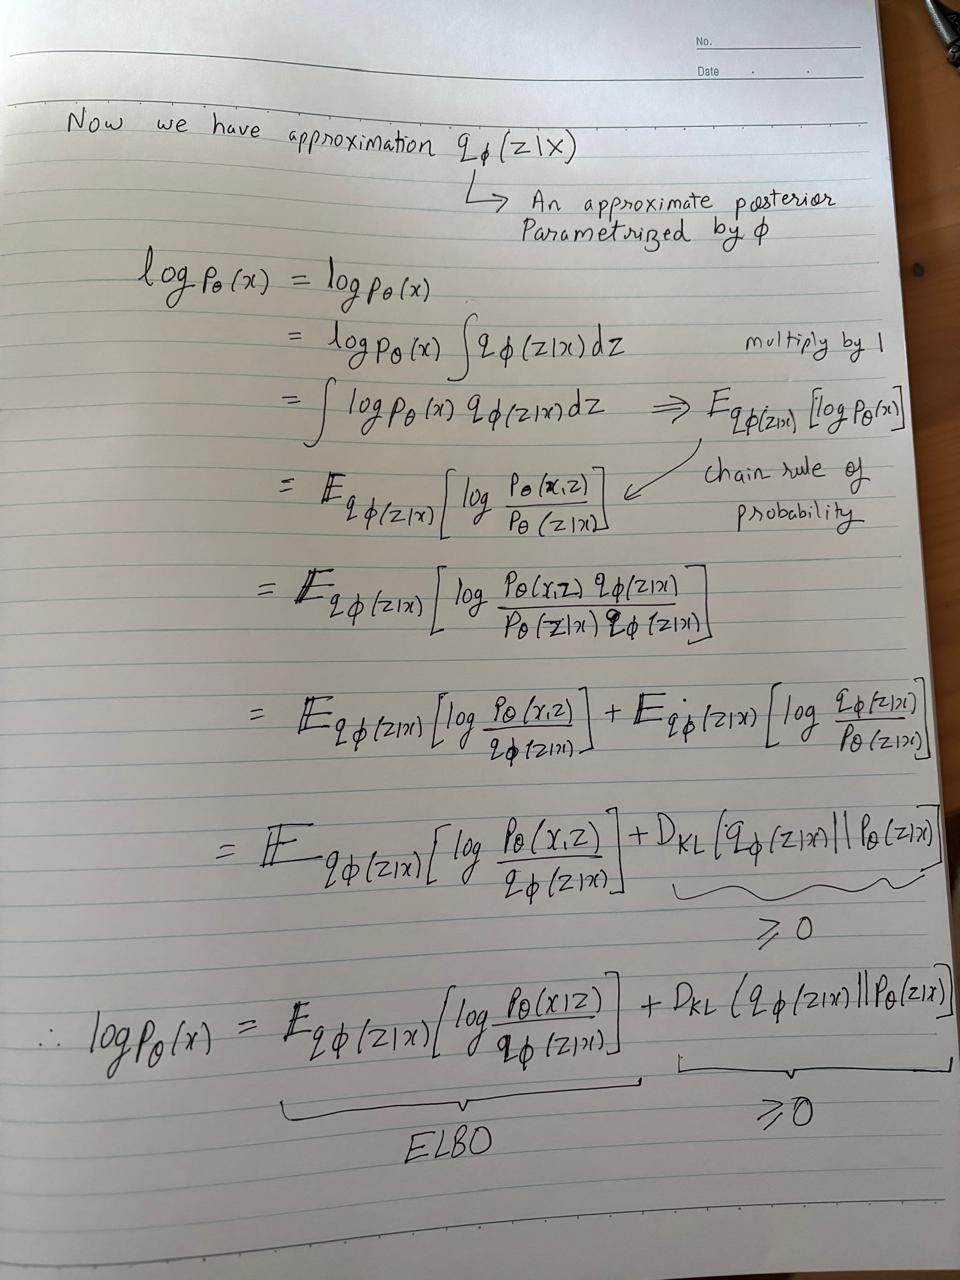

Explaination is below! 

### Deriving the ELBO

Since computing $p_\theta(x)$ directly is intractable, we introduce an **approximate posterior** $q_\phi(z \mid x)$, a distribution parameterized by $\phi$ that we use to approximate the true but unknown $p_\theta(z \mid x)$.

Our goal is to rewrite $\log p_\theta(x)$ in terms of this approximation.

---

**Step 1: Multiply by 1**

We start with $\log p_\theta(x)$ and multiply by 1 in a clever way. Since any probability distribution integrates to 1, we have $\int q_\phi(z \mid x)\, dz = 1$, so:

$$\log p_\theta(x) = \log p_\theta(x) \cdot \int q_\phi(z \mid x)\, dz = \int \log p_\theta(x) \cdot q_\phi(z \mid x)\, dz$$

This is just the expectation of $\log p_\theta(x)$ under $q_\phi(z \mid x)$:

$$= \mathbb{E}_{q_\phi(z \mid x)}\bigl[\log p_\theta(x)\bigr]$$

---

**Step 2: Apply the Chain Rule of Probability**

Using $p_\theta(x) = \dfrac{p_\theta(x, z)}{p_\theta(z \mid x)}$, we substitute inside the log:

$$= \mathbb{E}_{q_\phi(z \mid x)}\left[\log \frac{p_\theta(x, z)}{p_\theta(z \mid x)}\right]$$

---

**Step 3: Multiply numerator and denominator by $q_\phi(z \mid x)$**

This is another multiply by 1 trick. We introduce $q_\phi(z \mid x)$ in both numerator and denominator:

$$= \mathbb{E}_{q_\phi(z \mid x)}\left[\log \frac{p_\theta(x, z) \cdot q_\phi(z \mid x)}{p_\theta(z \mid x) \cdot q_\phi(z \mid x)}\right]$$

---

**Step 4: Split using log properties**

Using $\log(AB) = \log A + \log B$, we split the fraction:

$$= \mathbb{E}_{q_\phi(z \mid x)}\left[\log \frac{p_\theta(x, z)}{q_\phi(z \mid x)}\right] + \mathbb{E}_{q_\phi(z \mid x)}\left[\log \frac{q_\phi(z \mid x)}{p_\theta(z \mid x)}\right]$$

The second term is exactly the **KL divergence** between $q_\phi(z \mid x)$ and $p_\theta(z \mid x)$:

$$= \mathbb{E}_{q_\phi(z \mid x)}\left[\log \frac{p_\theta(x, z)}{q_\phi(z \mid x)}\right] + D_\text{KL}\bigl(q_\phi(z \mid x) \;\|\; p_\theta(z \mid x)\bigr)$$

---

**Step 5: Recognize the ELBO**

The KL divergence is always $\geq 0$. Therefore:

$$\log p_\theta(x) = \underbrace{\mathbb{E}_{q_\phi(z \mid x)}\left[\log \frac{p_\theta(x, z)}{q_\phi(z \mid x)}\right]}_{\text{ELBO}} + \underbrace{D_\text{KL}\bigl(q_\phi(z \mid x) \;\|\; p_\theta(z \mid x)\bigr)}_{\geq\, 0}$$

Since the KL term is non-negative, the ELBO is always a **lower bound** on $\log p_\theta(x)$:

$$\log p_\theta(x) \;\geq\; \mathbb{E}_{q_\phi(z \mid x)}\left[\log \frac{p_\theta(x, z)}{q_\phi(z \mid x)}\right]$$

---

**Why maximize the ELBO?**

We cannot directly maximize $\log p_\theta(x)$ because it is intractable. But we can maximize the ELBO instead. Since $\log p_\theta(x) = \text{ELBO} + D_\text{KL}$, maximizing the ELBO does two things simultaneously:

1. It pushes $\log p_\theta(x)$ up, making the model assign higher likelihood to observed data.
2. It pushes $D_\text{KL}$ down, meaning $q_\phi(z \mid x)$ becomes a better approximation to the true posterior $p_\theta(z \mid x)$.

This is the core objective of the **Variational Autoencoder**.